In [147]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, RepeatedKFold, ParameterGrid
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

import shap

from scipy.optimize import differential_evolution

import warnings
warnings.filterwarnings("ignore")

In [148]:
# Configuration
RANDOM_STATE = 42
TARGET_COL = "Removal %"
TIME_COL = "Rxn Time (min)"

In [149]:
df = pd.read_csv("../data/preprocessed_data.csv")
print(f"Loaded shape: {df.shape}")

df.sample(10, random_state=RANDOM_STATE)

Loaded shape: (161, 11)


,Dye,Rxn Time (min),Removal %,Full_Name,SMILES,LogP,HBD,HBA,Aromatic_Rings,Rotatable_Bonds,Fraction_Csp3
105,DR80,15,0.321952,Direct Red 80,C1=CC(=CC=C1N=NC2=CC(=C(C=C2)N=NC3=C(C=C4C=C(C...,-9.842,4,29,8,16,0.000
108,BF,0,0.000000,Basic Fuchsin,CC1=CC(=C(C2=CC=C(C=C2)N)C3=CC=C(C=C3)N)C=CC1=...,4.611,3,3,2,2,0.050
142,OG,20,0.833191,Orange G,C1=CC=C(C=C1)N=NC2=C(C=CC3=CC(=CC(=C32)S(=O)(=...,-3.223,1,9,3,4,0.000
55,PonS,5,0.298214,Ponceau S,C1=CC(=CC=C1N=NC2=CC(=C(C=C2)N=NC3=C4C=CC(=CC4...,-8.991,1,17,4,8,0.000
94,Reso,20,0.831068,Resorufin,C1=CC2=C(C=C1O)OC3=CC(=O)C=CC3=N2,1.998,1,4,1,0,0.000
29,R6G,25,0.758447,Rhodamine 6G,CCNC1=CC2=C(C=C1C)C(=C3C=C(C(=[NH+]CC)C=C3O2)C...,1.435,2,4,2,6,0.286
101,DMMB,25,0.709923,Dimethylmethylene Blue,CC1=CC(=CC2=C1N=C3C(=CC(=[N+](C)C)C=C3S2)C)N(C...,0.120,0,3,1,1,0.333
51,Ab,15,0.600005,Amido Black 10B,C1=CC=C(C=C1)N=NC2=C(C3=C(C(=C(C=C3C=C2S(=O)(=...,-1.317,2,14,4,7,0.000
100,DMMB,20,0.660136,Dimethylmethylene Blue,CC1=CC(=CC2=C1N=C3C(=CC(=[N+](C)C)C=C3S2)C)N(C...,0.120,0,3,1,1,0.333
143,OG,25,0.911265,Orange G,C1=CC=C(C=C1)N=NC2=C(C=CC3=CC(=CC(=C32)S(=O)(=...,-3.223,1,9,3,4,0.000


In [150]:
# dividing data to features and target
X = df.drop([TARGET_COL, "Dye", "Full_Name", "SMILES"], axis=1)
y = df[TARGET_COL]

feature_names = X.columns.tolist()

In [151]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [152]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(random_state=42, max_iter=50000))
])

In [153]:
# Define the parameter grid for tuning
param_grid = {
    'model__hidden_layer_sizes': [(19,), (11,), (13,)],
    'model__activation': ['tanh', 'relu'], # tanh better for small data sets
    'model__solver': ['lbfgs', 'sgd', 'adam'], # lbfgs for small
    'model__alpha': [0.07]
}

In [154]:
# Set up the GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1          # Use all available CPU cores
)

# Run the grid search
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__activation': ['tanh', 'relu'], 'model__alpha': [0.07], 'model__hidden_layer_sizes': [(19,), (11,), ...], 'model__solver': ['lbfgs', 'sgd', ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [155]:
# Print out the best parameters and cross-validation score
print("Best hyperparameters found:")
print(grid_search.best_params_)
print("\nBest cross-validation accuracy: {:.2f}%".format(grid_search.best_score_ * 100))

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Test set accuracy: {:.2f}%".format(test_accuracy * 100))

Best hyperparameters found:
{'model__activation': 'tanh', 'model__alpha': 0.07, 'model__hidden_layer_sizes': (13,), 'model__solver': 'lbfgs'}

Best cross-validation accuracy: 92.18%
Test set accuracy: 92.24%


In [156]:
# Predict & Evaluate
predictions = best_model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Model Performance: \n")
print(f"Mean Squared Error: {mse:.4f}")
print("RMSE: %f" % (rmse))
print(f"R^2 Score: {r2:.4f}")

Model Performance: 

Mean Squared Error: 0.0080
RMSE: 0.089646
R^2 Score: 0.9224


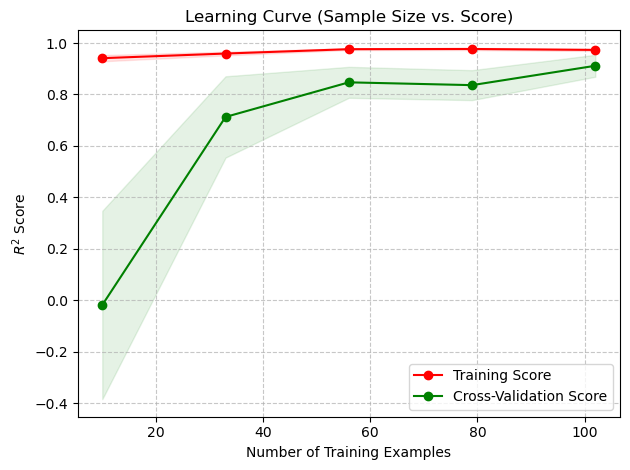

In [157]:
# Improved Learning Curve
# This shows if the model is underfitting, overfitting, or needs more data.
def plot_improved_learning_curve(estimator, X, y, title="Learning Curve (Sample Size vs. Score)"):
    # Calculate learning curve data
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='r2'
    )

    # Calculate mean and standard deviation for shading
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.title(title)
    plt.xlabel("Number of Training Examples")
    plt.ylabel("$R^2$ Score")

    # Draw shaded areas for standard deviation
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")

    # Plot the mean lines
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score")

    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# NOTE: We pass X_train and y_train to avoid leaking test data into the cross-validation
plot_improved_learning_curve(best_model, X_train, y_train)

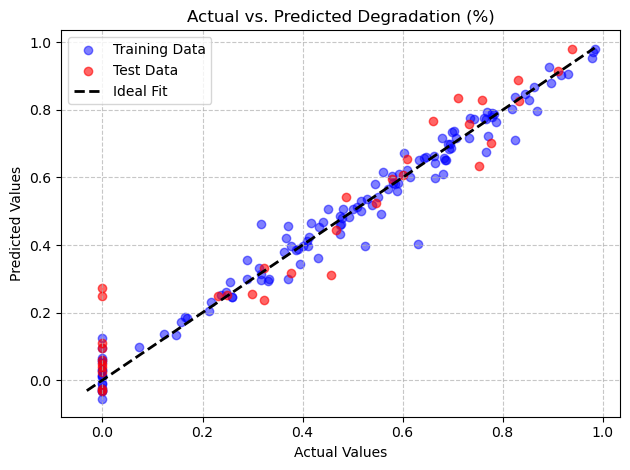

In [158]:
# Actual vs Predicted

y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

plt.scatter(y_train, y_pred_train, alpha=0.5, color='blue', label='Training Data')
plt.scatter(y_test, y_pred_test, alpha=0.6, color='red', label='Test Data')

# Plot the ideal 1:1 line
min_val = min(y.min(), y_pred_test.min())
max_val = max(y.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal Fit')

plt.title('Actual vs. Predicted Degradation (%)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

SHAP shape: (20, 7)


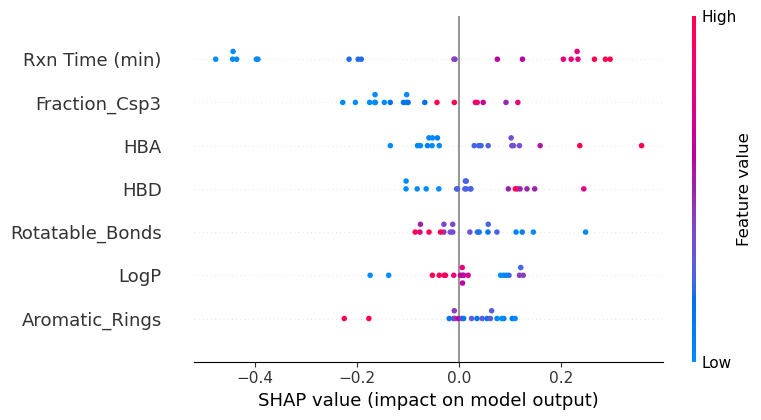

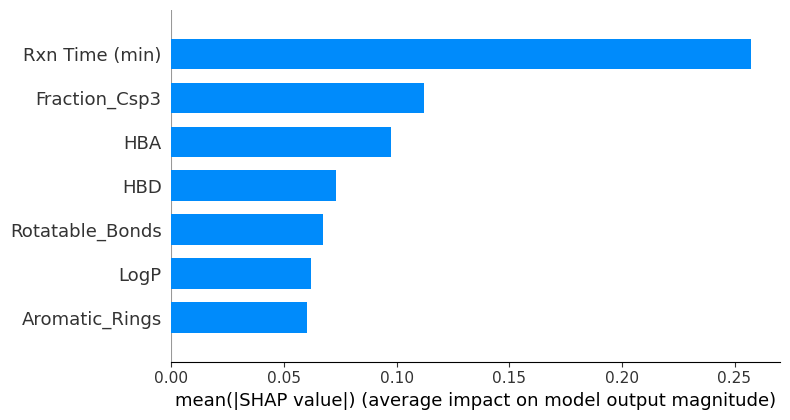

,Feature,Mean |SHAP value|
0,Rxn Time (min),0.257314
1,Fraction_Csp3,0.112016
2,HBA,0.097437
3,HBD,0.073083
4,Rotatable_Bonds,0.067387
5,LogP,0.062019
6,Aromatic_Rings,0.060346


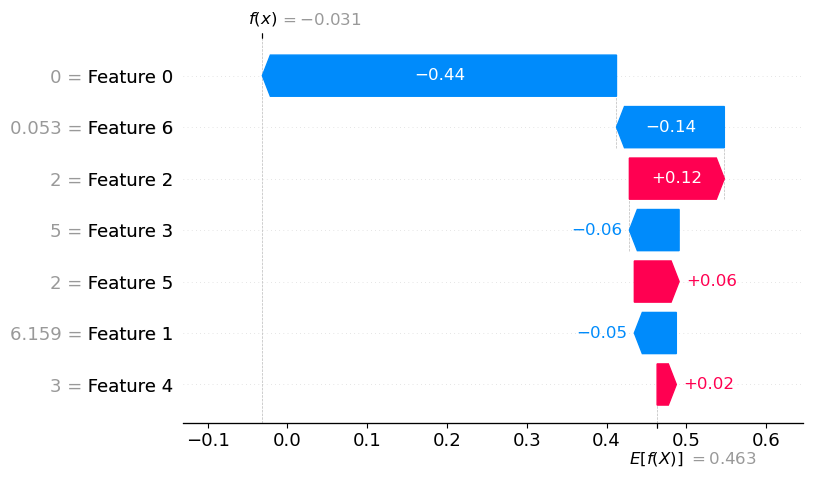

In [159]:
# SHAP ANALYSIS - FAST VERSION FOR MLP PIPELINE
feature_names = X.columns.tolist()

# Use small representative samples
X_background = X_train.sample(n=min(10, len(X_train)), random_state=42)
X_explain = X_test.sample(n=min(20, len(X_test)), random_state=42)

# Use numpy inside SHAP for speed
X_background_np = X_background.values
X_explain_np = X_explain.values

def model_predict_np(data):
    data_df = pd.DataFrame(data, columns=feature_names)
    return best_model.predict(data_df)

explainer = shap.PermutationExplainer(
    model_predict_np,
    X_background_np
)

shap_values = explainer(
    X_explain_np,
    max_evals=2 * len(feature_names) + 1
)

print("SHAP shape:", shap_values.values.shape)

# Convert explained data back to DataFrame for plotting
X_explain_df = pd.DataFrame(X_explain_np, columns=feature_names)

# Summary plot
shap.summary_plot(
    shap_values.values,
    X_explain_df,
    feature_names=feature_names
)

# Bar plot
shap.summary_plot(
    shap_values.values,
    X_explain_df,
    feature_names=feature_names,
    plot_type="bar"
)

shap_matrix = shap_values.values

mean_abs_shap = np.abs(shap_matrix).mean(axis=0)

shap_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Mean |SHAP value|": mean_abs_shap
    })
    .sort_values("Mean |SHAP value|", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance)

sample_index = 0
shap.plots.waterfall(shap_values[sample_index])